<a href="https://colab.research.google.com/github/pancakexia/machinelearning/blob/pancakexia_project/lab5_measurement_nurennetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [470]:
pip install scikit-datasets

In [471]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

In [472]:
data = load_iris()
#X, y = data(return_X_y=True)
X, y = data.data, data.target
X.shape, y.shape

((150, 4), (150,))

In [473]:

y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [474]:
# 1. Split data into 80% training and 20% test subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% of data used for the test set
    random_state=42,     # Ensures reproducibility
    shuffle=True         # Shuffle data before splitting
)

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit scaler on training data and transform the training set
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform the test set
X_test_scaled = scaler.transform(X_test)

# 5. Fit scaler on training data and transform the training set for y_train
# don't need StandardScaler, y is the lebal
# y_train = y_train.reshape(-1, 1)
# y_train_scaled = scaler.fit_transform(y_train)

# 6. Transform the test set
# y_test = y_test.reshape(-1, 1)
# y_test_scaled = scaler.transform(y_test)

In [475]:
# y_train

In [476]:
import numpy as np

def initialize_parameters(n_x, n_h, n_y, seed=42):
    """
    n_x: input layer (here 4)
    n_h: middle layer (here 8)
    n_y: output layer   (here 3)
    """
    np.random.seed(seed)
    W1 = np.random.randn(n_x, n_h) * 0.01   # 小随机数
    b1 = np.zeros((1, n_h))
    W2 = np.random.randn(n_h, n_y) * 0.01
    b2 = np.zeros((1, n_y))

    params = {
        "W1": W1, "b1": b1,
        "W2": W2, "b2": b2
    }
    return params

In [477]:
n_x = X_train_scaled.shape[1]
params = initialize_parameters(n_x, 8, 3)
print(params["W1"].shape, params["b1"].shape)  # (4,8) (1,8)
print(params["W2"].shape, params["b2"].shape)  # (8,3) (1,3)
W1 = params["W1"]
b1 = params["b1"]
W2 = params["W2"]
b2 = params["b2"]
x = X_train_scaled
def Forward_Propagation(x,W1,b1,W2,b2):
  # compute hidden‐layer
  z1 = x.dot(W1) + b1        # shape (1,8)
  #a1 = np.maximum(0, z1)           #max function  shape (1,8)
  a1=1.0 / (1.0 + np.exp(-z1)) #sigmoid function
  #a1.shape
  # compute output layer
  z2 = a1.dot(W2) + b2        # shape (1,3)
  #如果直接 np.exp(z2)，当某个 z_{i,k} 很大时 e^{z_{i,k}} 会溢出。
  exp_z2 = np.exp(z2 - np.max(z2, axis=1, keepdims=True))#axis=1 表示“每行做求和／减最大值”
  a2 = exp_z2 / exp_z2.sum(axis=1, keepdims=True)  # (m,3)#	keepdims=True 保留 (m,1) 的维度以便广播回 (m,3)。
  #a2=np.exp(z2)/sum(np.exp(z2))#softmax function
  #a2.shape
  return z1,a1,z2,a2

(4, 8) (1, 8)
(8, 3) (1, 3)


In [478]:
# from sklearn.preprocessing import OneHotEncoder
# drop_enc = OneHotEncoder(drop='first').fit(y)
K = 3
y_train = np.eye(K, dtype=int)[y_train]
y_train.shape

(120, 3)

In [479]:
# z1,a1, z2, a2 = Forward_Propagation(X_train_scaled,W1,b1,W2,b2)
# compute loss
loss = -np.mean(np.sum(y_train * np.log(a2), axis=1))  # categorical cross-ent; #m is number of nerron

In [480]:
# n_x = X_train_scaled.shape[1]
# n_Y=Y.shape[1]
# params_back = initialize_parameters(n_Y, 8, n_x)
# print(params_back["W1"].shape, params_back["b1"].shape)  # (3, 8) (1, 8)
# print(params_back["W2"].shape, params_back["b2"].shape)  # (8, 4) (1, 4)
# W2_back = params["W1"]
# b2_back = params["b1"]
# W1_back = params["W2"]
# b1_back = params["b2"]
# # here is doing opzite

In [481]:
# backpropagation process
def backpropagation(X_train_scaled,y_train,a2,a1,z1):
  # dz_2=a2-y_train;
  # dw_2=np.mean(np.sum(np.dot(a1.T, dz_2), axis=1)) #m is number of nerron
  # db_2=np.mean(np.sum(dz_2, axis=1))
  # # 1.0 / (1.0 + np.exp(-z)) sigmoid
  # s=1.0 / (1.0 + np.exp(-z1))
  # dz_1=dz_2@W2.T@(s * (1 - s)).T
  # dz_1.shape
  # dw_1=np.mean(np.sum(X_train_scaled.T@dz_1, axis=1))
  # db_1=np.mean(np.sum(dz_1, axis=1))
  m = X_train_scaled.shape[0]
  dz_2= a2-y_train
  dw_2=a1.T@ dz_2/m
  db_2=np.sum(dz_2, axis=0,keepdims=True)/m
  # db_2 = np.sum(dZ2, axis=0, keepdims=True) / m  # (1, n_y)
  dz_1=dz_2@W2.T*(a1*(1-a1))#connot use the @,use*,σ′(z)still the 120*8,not 120*120
  dw_1=X_train_scaled.T@dz_1/m
  db_1=np.sum(dz_1, axis=0,keepdims=True)/m
  return dz_2,dw_2,db_2,dz_1,dw_1,db_1

In [482]:
np.sum(dz_1, axis=0,keepdims=True)

array([[-0.20953053, -0.22745411, -0.00348514, -0.19712064, -0.02133988,
        -0.20328025, -0.02289833, -0.02086199]])

In [483]:
m = X_train_scaled.shape[0]
print (m)
dz_2= a2-y_train
dz_2.shape

120


(120, 3)

In [484]:
qq=a1*(1-a1)
qq.shape

(120, 8)

In [485]:
lr=0.1 # it's the step for Gradients
def Gradients(W1,b1,W2,b2,dw_1,dw_2,db_1,db_2,loss,lr):
#Parameter update.
  W1=W1-lr*dw_1
  b1=b1-lr*db_1
  W2=W2-lr*dw_2
  b2=b2-lr*db_2
  return W1,b1,W2,b2

In [486]:
# lr=0.1 # it's the step for Gradients
# def mini_betch_Gradients(W1,b1,W2,b2,dw_1,dw_2,db_1,db_2,loss,lr):
# how to do the mini betch????

In [487]:
# K = 3
# y_train = np.eye(K, dtype=int)[y_train]
epochs=4000
lr=0.1 # it's the step for Gradients
n_x = X_train_scaled.shape[1]
params = initialize_parameters(n_x, 8, 3)
W1 = params["W1"]
b1 = params["b1"]
W2 = params["W2"]
b2 = params["b2"]
loss_history = []
for i in range(epochs):
  z1,a1, z2, a2 = Forward_Propagation(X_train_scaled,W1,b1,W2,b2)
  # compute loss
  loss = -np.mean(np.sum(y_train * np.log(a2), axis=1))  # categorical cross-ent; #m is number of nerron
  loss_history.append(loss)
  dz_2,dw_2,db_2,dz_1,dw_1,db_1 = backpropagation(X_train_scaled,y_train,a2,a1,z1)
  W1,b1,W2,b2=Gradients(W1,b1,W2,b2,dw_1,dw_2,db_1,db_2,loss,lr)
# print(W1,b1,W2,b2)


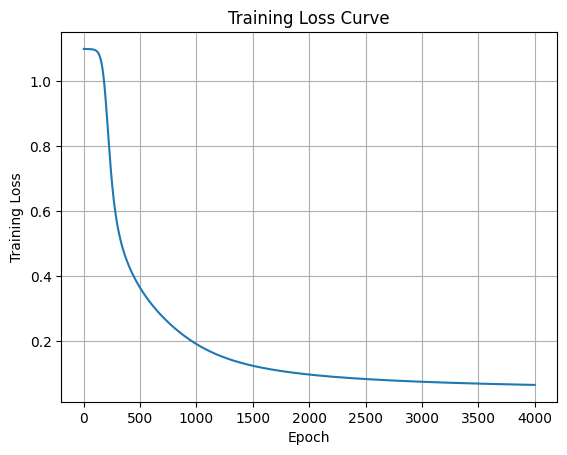

In [488]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()
# the loss curve still high

In [489]:
y_train_idx = y_train.copy()   #  (120,)
y_test_idx  = y_test.copy()    #  (30,)

In [490]:
def predict(input, W1, b1, W2, b2):
  z1,a1,z2,a2=Forward_Propagation(input,W1,b1,W2,b2)
  return a2

In [496]:
y_train_pred = predict(X_train_scaled, W1, b1, W2, b2)
y_test_pred  = predict(X_test_scaled,  W1, b1, W2, b2) #b1 should be (1,8), not (120,8);b2 should be (1,3), not (120,3)
y_train_pred = np.argmax(y_train_pred, axis=1,keepdims=True)# need(120,1),not (120,)
y_test_pred = np.argmax(y_test_pred, axis=1,keepdims=True)# need(30,1),not (30,)
train_acc = np.mean(y_train_pred == y_train_idx)
test_acc  = np.mean(y_test_pred  == y_test_idx)
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test  accuracy: {test_acc*100:.2f}%")

Train accuracy: 33.33%
Test  accuracy: 33.56%


In [495]:
y_train_pred

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 2, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])